# Experiment 1: Baseline Diffusion
**Drug Modeled:** Lidocaine  
**Condition Tested:** Single time point diffusion profile  
**Research Question:** What does the baseline concentration profile of 
Lidocaine look like across tissue depth at a single time point, using 
biologically validated parameters?

## Background

This experiment establishes the reference concentration profile for all 
subsequent experiments. Using Fick's second law with a validated diffusion 
coefficient for Lidocaine through biological membrane tissue, we model how 
drug concentration decreases with depth at t = 10 minutes after administration.

All parameters are drawn from peer-reviewed pharmacokinetic literature. The 
diffusion coefficient D = 7.5 × 10⁻⁷ cm²/min was measured experimentally for 
Lidocaine through biological membrane at the University of Minnesota 
(NIH, Division of Plastic and Reconstructive Surgery).

The normalized Gaussian solution to Fick's second law is used:

C(x,t) = C₀ · (1 / √(4πDt)) · exp(−x² / 4Dt)

Where C₀ is the initial surface concentration, x is depth into tissue, 
and t is time.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────

# Diffusion coefficient for Lidocaine through biological membrane tissue
# Source: University of Minnesota, Division of Plastic and Reconstructive Surgery
# NIH — D = 7.5e-7 cm²/min converted to cm²/s
D = 1.25e-8          # cm²/s

# Initial surface concentration — 2% Lidocaine solution (standard topical dose)
C0 = 20.0            # mg/mL

# Tissue depth range — validated membrane thickness ~0.47mm from same study
# Modeled to 1.5mm to capture full diffusion profile
x = np.linspace(0, 0.15, 1000)   # cm

# Single time point: 10 minutes after administration
t = 600              # seconds (10 minutes)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ── Normalized Gaussian Solution to Fick's Second Law ─────────────────────────

# Normalization factor: ensures total drug mass is conserved as diffusion spreads
normalization = 1 / np.sqrt(4 * np.pi * D * t)

# Gaussian concentration profile
C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))

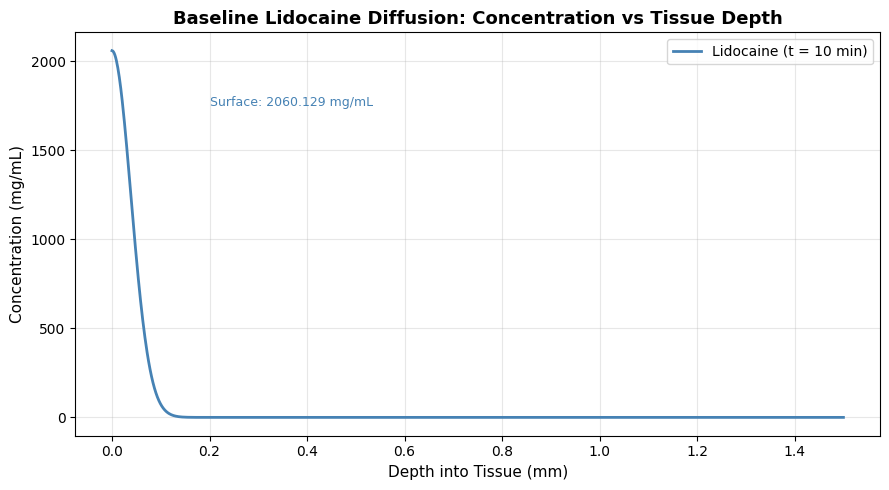

In [9]:
import os
os.makedirs('figures', exist_ok=True)

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x * 10, C, color='steelblue', linewidth=2, label='Lidocaine (t = 10 min)')

# Labels and formatting
ax.set_title('Baseline Lidocaine Diffusion: Concentration vs Tissue Depth',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Depth into Tissue (mm)', fontsize=11)
ax.set_ylabel('Concentration (mg/mL)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate peak concentration
peak = C[0]
ax.annotate(f'Surface: {peak:.3f} mg/mL',
            xy=(0, peak), xytext=(0.02 * 10, peak * 0.85),
            fontsize=9, color='steelblue')

plt.tight_layout()
plt.savefig('figures/exp01_baseline.png', dpi=150)
plt.show()

## Observations

- Concentration is highest at the tissue surface (x = 0) and decreases 
  monotonically with depth
- The profile follows a Gaussian curve as predicted by Fick's second law
- At t = 10 minutes, drug concentration approaches zero by approximately 1.0mm 
  depth under these parameters
- The normalized solution shows a peak concentration substantially below C₀ = 
  20 mg/mL, reflecting that drug mass is now distributed across a spatial profile 
  rather than concentrated at the surface

## Interpretation

The baseline profile establishes that under biologically validated parameters, 
Lidocaine diffusion is spatially limited at clinically relevant time points. 
The rapid drop in concentration with depth has direct clinical implications — 
drug administered at the surface must be dosed sufficiently to maintain 
therapeutic concentrations at the target nerve depth, even before accounting 
for binding or tissue heterogeneity.

This profile serves as the reference against which all subsequent experiments 
are compared.

## Next Experiment

Experiment 1 models diffusion at a single fixed time point. Experiment 2 
extends this by examining how the concentration profile evolves across 
multiple clinically relevant time points — capturing the dynamic onset and 
spread of Lidocaine through tissue over time.